In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train=pd.read_csv('/content/train.csv')
test=pd.read_csv('/content/test.csv')
sample=pd.read_csv('/content/sample_submission.csv')

In [ ]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


In [ ]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

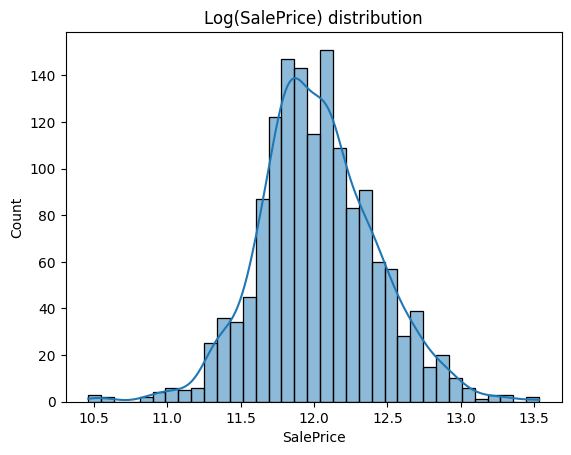

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [ ]:
# basic info + SalePrice
print(train.info())
print(train['SalePrice'].describe())

# distribution of target (SalePrice)
sns.histplot(np.log1p(train['SalePrice']), kde=True)
plt.title("Log(SalePrice) distribution")
plt.show()

# missing values (percentage)
missing = train.isnull().sum().sort_values(ascending=False)
missing_perc = (missing / len(train) * 100).loc[missing>0]
print(missing_perc)


In [ ]:
y = np.log1p(train['SalePrice'])
train_ID = train['Id']
test_ID = test['Id']

# drop target from train for concatenation
train_X = train.drop(['SalePrice'], axis=1)
# combine for uniform preprocessing
full = pd.concat([train_X, test], axis=0).reset_index(drop=True)


In [ ]:
# ---- fill categorical NA that mean 'No feature' ----
cols_fill_none = [
 'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
 'GarageType','GarageFinish','GarageQual','GarageCond',
 'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
 'MasVnrType'
]
for c in cols_fill_none:
    if c in full.columns:
        full[c] = full[c].fillna('None')

# numeric features where NA -> 0
cols_fill_zero = [
 'MasVnrArea','GarageArea','GarageCars','BsmtFinSF1','BsmtFinSF2',
 'BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath','PoolArea'
]
for c in cols_fill_zero:
    if c in full.columns:
        full[c] = full[c].fillna(0)

# GarageYrBlt: fill NA with YearBuilt (common practice)
if 'GarageYrBlt' in full.columns:
    full['GarageYrBlt'] = full['GarageYrBlt'].fillna(full['YearBuilt'])

# LotFrontage: fill by neighborhood median
if 'LotFrontage' in full.columns and 'Neighborhood' in full.columns:
    full['LotFrontage'] = full.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# fill any remaining small nulls with mode (e.g., Electrical)
for c in ['Electrical','KitchenQual','MSZoning','Exterior1st','Exterior2nd','SaleType']:
    if c in full.columns:
        full[c] = full[c].fillna(full[c].mode()[0])


In [ ]:
# totals + ages + binary flags
full['TotalSF'] = full['TotalBsmtSF'] + full['1stFlrSF'] + full['2ndFlrSF']
full['TotalBath'] = full['FullBath'] + 0.5*full['HalfBath'] + full['BsmtFullBath'] + 0.5*full['BsmtHalfBath']
full['HouseAge'] = full['YrSold'] - full['YearBuilt']
full['RemodAge']  = full['YrSold'] - full['YearRemodAdd']

full['HasPool'] = (full['PoolArea'] > 0).astype(int)
full['HasGarage'] = (full['GarageArea'] > 0).astype(int)
full['HasBsmt'] = (full['TotalBsmtSF'] > 0).astype(int)
full['HasFireplace'] = (full['Fireplaces'] > 0).astype(int)


In [ ]:
qual_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'None':0}
ord_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
            'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
for c in ord_cols:
    if c in full.columns:
        full[c] = full[c].map(qual_map).fillna(0).astype(int)

# Simple binary for central air
if 'CentralAir' in full.columns:
    full['CentralAir'] = full['CentralAir'].map({'Y':1,'N':0})


In [ ]:
full = pd.get_dummies(full)
# fill any remaining NaNs (safety)
full = full.fillna(0)


In [ ]:
n_train = train_X.shape[0]
X = full.iloc[:n_train, :].copy()
X_test = full.iloc[n_train:, :].copy()
print("X shape:", X.shape, "X_test shape:", X_test.shape)


X shape: (1460, 270) X_test shape: (1459, 270)


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model, X, y):
    # scoring = neg_root_mean_squared_error is available in recent sklearn
    scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
    return -scores.mean()


In [ ]:
# baseline models
models = {
    'Lasso': Lasso(alpha=0.0005, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=2000, learning_rate=0.05, max_depth=4, subsample=0.5, random_state=42)
}

for name, m in models.items():
    print(name, "CV RMSE (log):", cv_rmse(m, X, y))


Lasso CV RMSE (log): 0.14151794427749564
RandomForest CV RMSE (log): 0.14316584786033285
GradientBoosting CV RMSE (log): 0.12856567466394295


In [ ]:
# stacking example (simple)
stack_est = [
    ('rf', models['RandomForest']),
    ('gbr', models['GradientBoosting'])
]
stack = StackingRegressor(estimators=stack_est, final_estimator=Lasso(alpha=0.0005, random_state=42), n_jobs=-1)
print("Stacking CV RMSE (log):", cv_rmse(stack, X, y))


Stacking CV RMSE (log): 0.12874391884166508


In [ ]:
# choose final_model based on CV results, e.g. 'stack' or a tuned xgboost
final_model = stack  # or models['GradientBoosting'] or your best model

# fit on full training data (log target)
final_model.fit(X, y)

# predict on test, invert log1p
preds_log = final_model.predict(X_test)
preds = np.expm1(preds_log)



In [ ]:

submission = pd.DataFrame({'Id': test_ID, 'SalePrice': preds})
submission.to_csv('/content/sample_submission.csv', index=False)
print("Saved /mnt/data/submission.csv")

Saved /mnt/data/submission.csv


In [ ]:
pip install scikit-learn xgboost lightgbm shap lime optuna matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 16.2 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b82ec6074bd880f4164f4ffb690ed9da332255117737a7056037e68614eb7f4b
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# helper metrics (we use log-target: y = np.log1p(SalePrice))
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle_origscale(y_true_price, y_pred_price):
    # if you have predictions in original price space
    return np.sqrt(mean_squared_error(np.log1p(y_true_price), np.log1p(y_pred_price)))

def cv_score(model, X, y):
    # evaluate on log-target using neg_root_mean_squared_error if available
    scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
    return -scores.mean()  # return positive rmse on log-target

# Example: evaluate a fitted model on holdout split (demonstration)
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Random Forest tuning
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist_rf = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [6, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5, 0.7, None]
}

rs_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf,
                           n_iter=30, scoring='neg_root_mean_squared_error',
                           cv=kf, verbose=2, n_jobs=-1, random_state=42)

rs_rf.fit(X_tr, y_tr)  # on log-target
print("Best RF params:", rs_rf.best_params_)
print("Best RF CV (log-RMSE):", -rs_rf.best_score_)
best_rf = rs_rf.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}
Best RF CV (log-RMSE): 0.1404686979861732


In [ ]:
# XGBoost tuning example
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

xg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0)

param_dist_xgb = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.02, 0.05],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.5, 0.7, 0.8, 1],
    'colsample_bytree': [0.4, 0.6, 0.8, 1],
    'reg_alpha': [0, 0.001, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

rs_xgb = RandomizedSearchCV(xg, param_distributions=param_dist_xgb,
                            n_iter=40, scoring='neg_root_mean_squared_error',
                            cv=kf, verbose=2, n_jobs=-1, random_state=42)

rs_xgb.fit(X_tr, y_tr)
print("Best XGB params:", rs_xgb.best_params_)
print("Best XGB CV (log-RMSE):", -rs_xgb.best_score_)
best_xgb = rs_xgb.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.4}
Best XGB CV (log-RMSE): 0.12332720456297575


In [ ]:
# choose final model (example using best_xgb found)
final_model = best_xgb  # or best_rf or stack

final_model.fit(X, y)  # fit on full training set (log-target)

# predictions on validation (if you kept X_val)
y_val_pred_log = final_model.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)   # convert to original price
y_val_true = np.expm1(y_val) if isinstance(y_val, np.ndarray) else np.expm1(y_val)  # if y_val is log

# metrics on original price scale
print("RMSE on validation (original price):", np.sqrt(mean_squared_error(y_val_true, y_val_pred)))
print("MAE on validation (original price):", mean_absolute_error(y_val_true, y_val_pred))
print("R2 on validation (original price):", r2_score(y_val_true, y_val_pred))

# metrics on log-target (competition metric)
print("RMSE on validation (log-target):", rmse(y_val, y_val_pred_log))


RMSE on validation (original price): 9279.255607951036
MAE on validation (original price): 6446.9018799943005
R2 on validation (original price): 0.9893941150966185
RMSE on validation (log-target): 0.04534167121918676


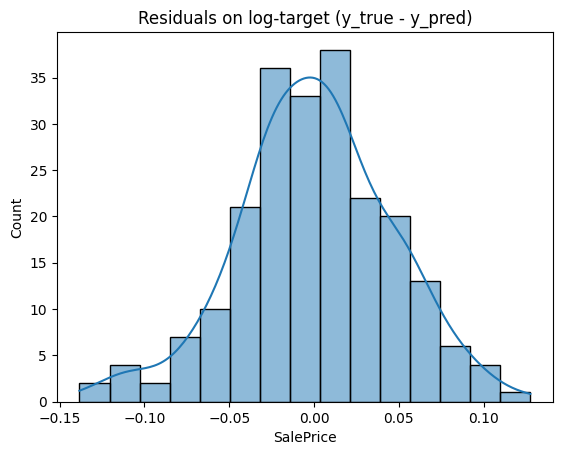

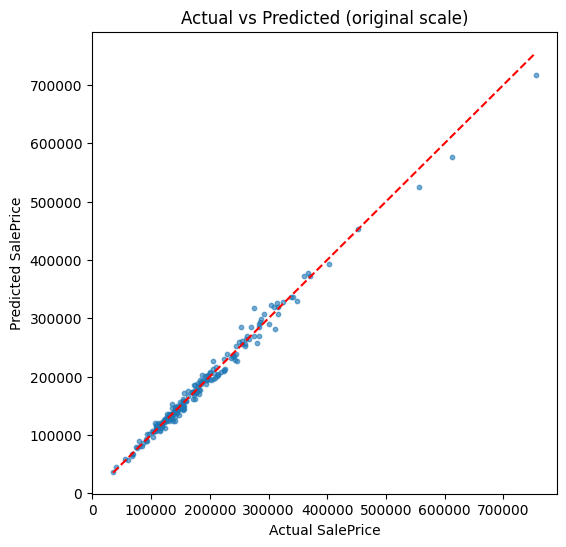

Median percentage error: 2.7212701612902648 %
Mean percentage error: 3.534316676555905 %


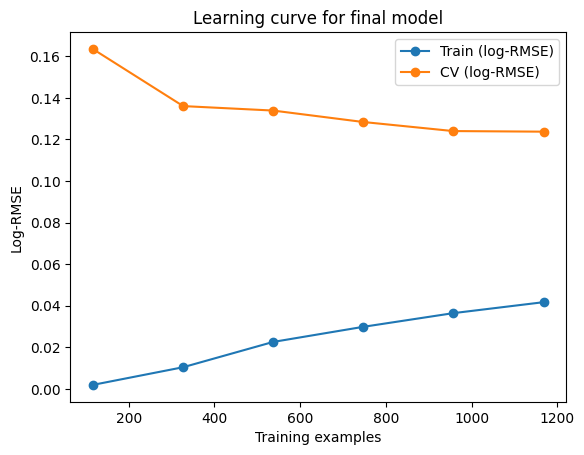

In [ ]:
# Residuals plot (log-target)
resid = y_val - y_val_pred_log
sns.histplot(resid, kde=True)
plt.title("Residuals on log-target (y_true - y_pred)")
plt.show()

# Actual vs Predicted (original scale)
plt.figure(figsize=(6,6))
plt.scatter(y_val_true, y_val_pred, s=10, alpha=0.6)
plt.plot([y_val_true.min(), y_val_true.max()], [y_val_true.min(), y_val_true.max()], 'r--')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted (original scale)")
plt.show()

# Prediction error percentiles
errors = (y_val_pred - y_val_true) / y_val_true
print("Median percentage error:", np.median(np.abs(errors))*100, "%")
print("Mean percentage error:", np.mean(np.abs(errors))*100, "%")

# Learning curve function
from sklearn.model_selection import learning_curve
def plot_learning_curve(estimator, X, y, title='Learning Curve'):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, train_sizes=np.linspace(0.1,1.0,6))
    train_scores_mean = -train_scores.mean(axis=1)
    val_scores_mean = -val_scores.mean(axis=1)
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Train (log-RMSE)')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='CV (log-RMSE)')
    plt.xlabel("Training examples")
    plt.ylabel("Log-RMSE")
    plt.title(title)
    plt.legend()
    plt.show()

plot_learning_curve(final_model, X, y, title='Learning curve for final model')


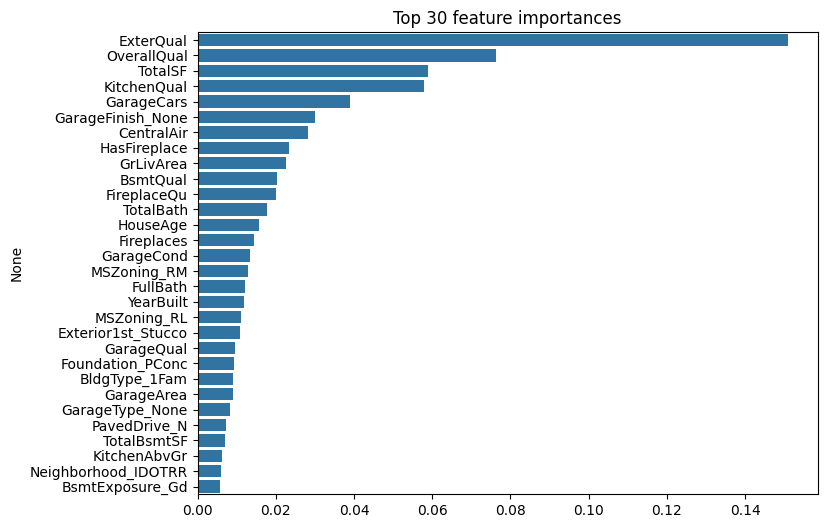

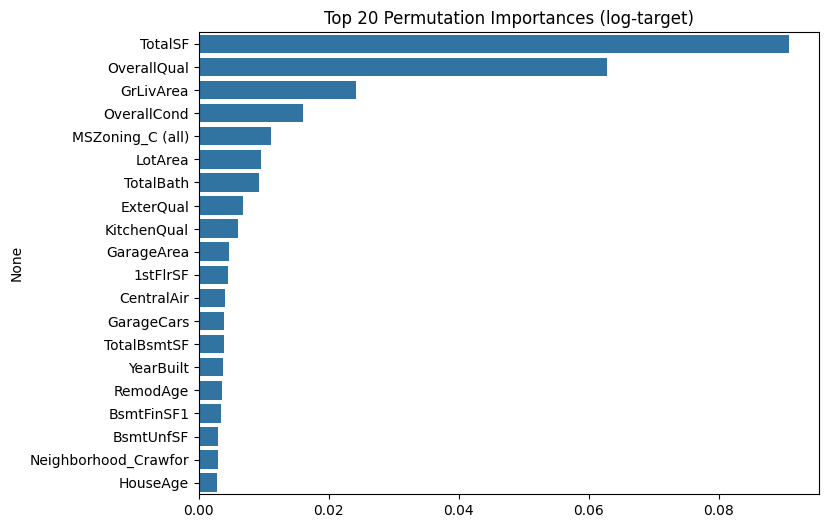

In [ ]:
# Feature importance (XGBoost / tree)
if hasattr(final_model, 'feature_importances_'):
    fi = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)[:30]
    plt.figure(figsize=(8,6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title("Top 30 feature importances")
    plt.show()

# Permutation importance (model-agnostic)
from sklearn.inspection import permutation_importance
perm = permutation_importance(final_model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
perm_idx = perm.importances_mean.argsort()[::-1][:20]
top_perm = pd.Series(perm.importances_mean[perm_idx], index=X.columns[perm_idx])
plt.figure(figsize=(8,6))
sns.barplot(x=top_perm.values, y=top_perm.index)
plt.title("Top 20 Permutation Importances (log-target)")
plt.show()


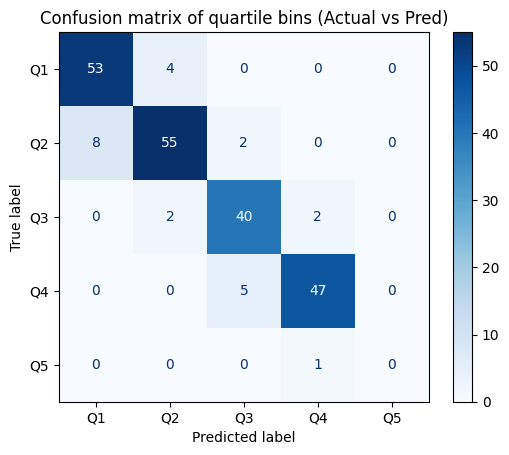

              precision    recall  f1-score   support

          Q1       0.87      0.93      0.90        57
          Q2       0.90      0.85      0.87        65
          Q3       0.85      0.91      0.88        44
          Q4       0.94      0.90      0.92        52
          Q5       0.00      0.00      0.00         1

    accuracy                           0.89       219
   macro avg       0.71      0.72      0.71       219
weighted avg       0.89      0.89      0.89       219



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# create quartile buckets on true prices (original scale) and predictions
y_val_true_prices = y_val_true
y_val_pred_prices = y_val_pred

bins = np.quantile(np.expm1(y), [0, 0.25, 0.5, 0.75, 1.0])  # quartiles from full train
y_true_bin = np.digitize(y_val_true_prices, bins) - 1
y_pred_bin = np.digitize(y_val_pred_prices, bins) - 1

cm = confusion_matrix(y_true_bin, y_pred_bin)
# Provide 5 labels for the 5 bins
disp = ConfusionMatrixDisplay(cm, display_labels=['Q1','Q2','Q3','Q4','Q5'])
disp.plot(cmap='Blues')
plt.title("Confusion matrix of quartile bins (Actual vs Pred)")
plt.show()

print(classification_report(y_true_bin, y_pred_bin, target_names=['Q1','Q2','Q3','Q4','Q5']))

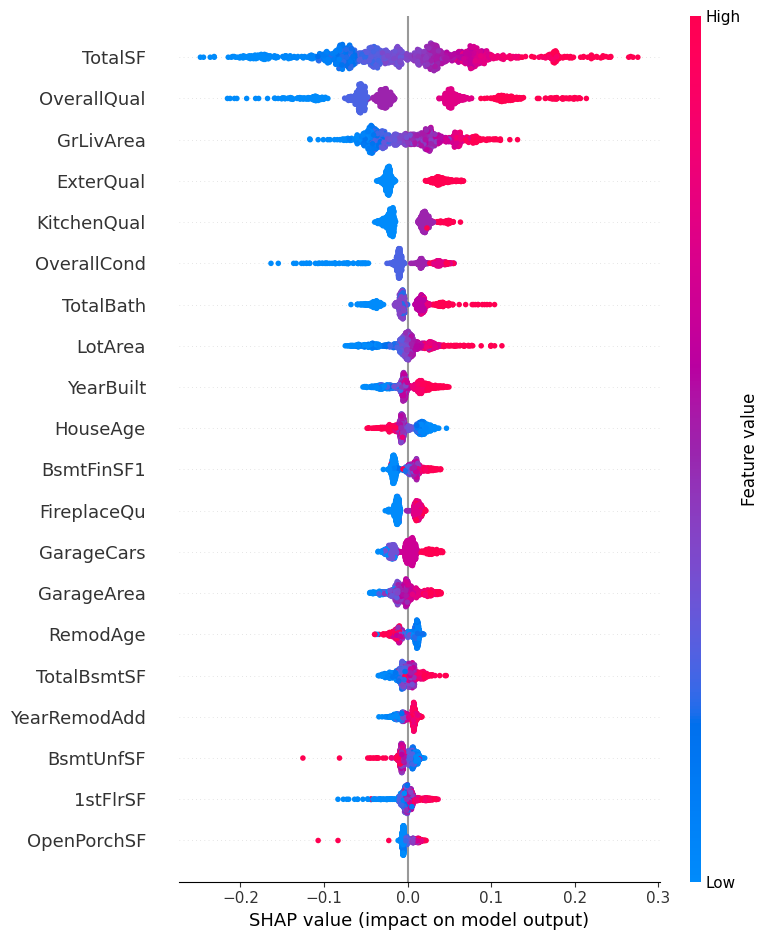

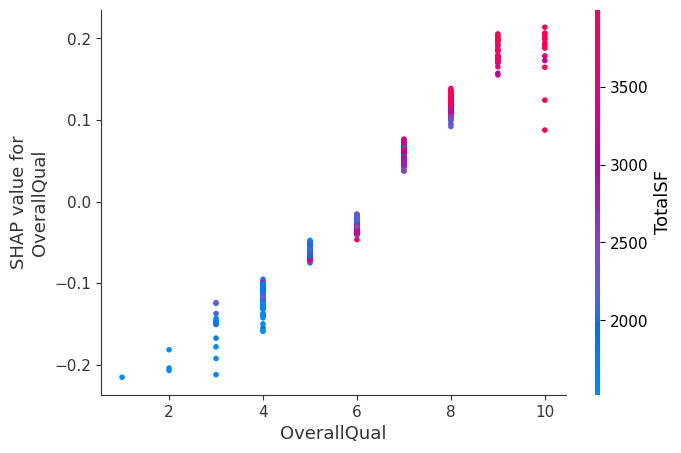

In [ ]:
import shap

# For tree models use TreeExplainer (fast and exact-ish)
explainer = shap.TreeExplainer(final_model)   # for XGB/LightGBM/RF
# choose a sample to speed things up (or full X)
sample = X.sample(1000, random_state=42) if X.shape[0] > 1000 else X
shap_values = explainer.shap_values(sample)  # shape (n_samples, n_features) for reg

# summary plot (global importance + effect)
shap.summary_plot(shap_values, sample, plot_type="dot")   # shows top features and their impact

# dependence plot for a single feature
shap.dependence_plot("OverallQual", shap_values, sample)  # change feature name as present in X.columns

# force plot for a single example (interactive) - in notebook
idx = 5
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[idx,:], sample.iloc[idx,:])


In [ ]:
from lime import lime_tabular

# LIME needs raw features (not dummy-expanded) ideally. If you used pd.get_dummies you can still explain using the transformed matrix.
explainer_lime = lime_tabular.LimeTabularExplainer(training_data=np.array(X), feature_names=X.columns.tolist(), mode='regression')

i = 10  # index of instance in validation set to explain
exp = explainer_lime.explain_instance(X_val.iloc[i].values, final_model.predict, num_features=10)
exp.show_in_notebook(show_table=True)  # if in notebook
print(exp.as_list())


[('RoofMatl_ClyTile <= 0.00', -0.2103464644759002), ('MiscFeature_Gar2 <= 0.00', -0.15504348871787899), ('SaleType_CWD <= 0.00', -0.13871037180602222), ('MSZoning_C (all) <= 0.00', 0.13498476231297238), ('RoofMatl_WdShake <= 0.00', 0.10714493696873055), ('6.00 < OverallQual <= 7.00', 0.10302882583496485), ('Exterior2nd_CBlock <= 0.00', -0.09440491036978527), ('Electrical_Mix <= 0.00', 0.08729913320746675), ('MiscFeature_TenC <= 0.00', -0.060885855905037534), ('Exterior1st_BrkComm <= 0.00', -0.04878588186092277)]


Saved submission and assets to /content/


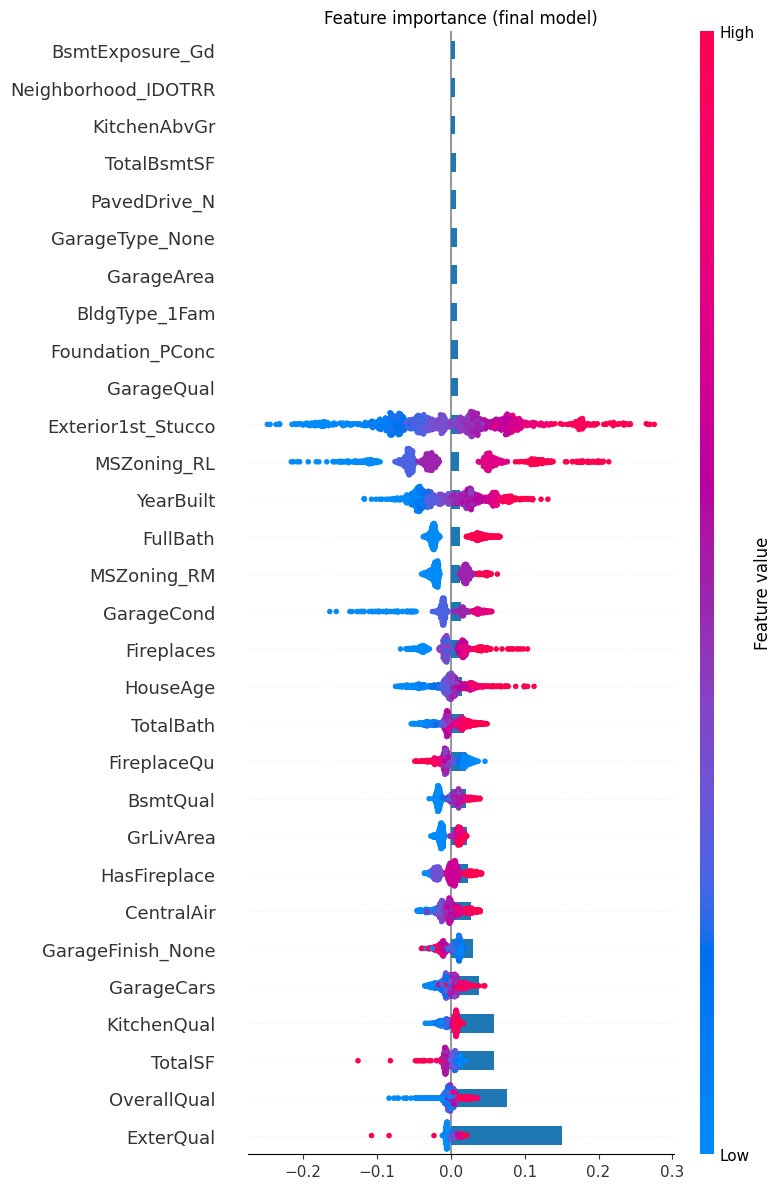

In [ ]:
# 1) save model (joblib)
import joblib-
joblib.dump(final_model, '/content/final_model.pkl')

# 2) save shap summary to PNG (requires matplotlib backend)
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, sample, show=False)
plt.savefig('/content/shap_summary.png', bbox_inches='tight')

# 3) save feature importance plot
fi.plot(kind='barh', figsize=(8,12))
plt.title("Feature importance (final model)")
plt.tight_layout()
plt.savefig('/content/feature_importance.png')

# 4) save submission
preds_test_log = final_model.predict(X_test)
preds_test = np.expm1(preds_test_log)
submission = pd.DataFrame({'Id': test_ID, 'SalePrice': preds_test})
submission.to_csv('/content/submission.csv', index=False)
print("Saved submission and assets to /content/")